**Required Libraries**

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, label_binarize
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords  # Import stopwords
from nltk.stem import PorterStemmer
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import lime
import lime.lime_text
from imblearn.under_sampling import RandomUnderSampler

**Download stopwords**

In [2]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kiran\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kiran\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**Load dataset**

In [3]:
df = pd.read_csv(r'C:\Users\kiran\Downloads\Yelp JSON\reviews.csv')

**Top 5 Records in dataset**

In [4]:
df.head(5)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


**Shape of the dataset**

In [5]:
df.shape

(100000, 9)

**Text data procssing by Tokenization, Stop Words, Stemming**

In [6]:
# Clean the text, convert to lowercase, remove non-alphabet characters, tokenize, apply stemming, and remove stopwords
def preprocess_text(text):
    text = text.lower().strip() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabet characters
    tokens = word_tokenize(text)  # Tokenize text into words
    stop_words = set(stopwords.words('english'))  # Set of English stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    stemmer = PorterStemmer()  # Initialize the Porter Stemmer
    tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    return ' '.join(tokens)  # Join tokens back into a string

**New Column to Store Processed dataset**

In [7]:
df['processed_text'] = df['text'].apply(preprocess_text)  # Applying preprocessing to the reviews

In [8]:
df.head(5)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,processed_text
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,decid eat awar go take hour begin end tri mult...
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,ive taken lot spin class year noth compar clas...
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,famili diner buffet eclect assort larg chicken...
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,wow yummi differ delici favorit lamb curri kor...
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,cute interior owner gave us tour upcom patioro...


**Original text & processed text**

In [9]:
df[['text', 'processed_text']]

,text,processed_text
0,"If you decide to eat here, just be aware it is...",decid eat awar go take hour begin end tri mult...
1,I've taken a lot of spin classes over the year...,ive taken lot spin class year noth compar clas...
2,Family diner. Had the buffet. Eclectic assortm...,famili diner buffet eclect assort larg chicken...
3,"Wow! Yummy, different, delicious. Our favo...",wow yummi differ delici favorit lamb curri kor...
4,Cute interior and owner (?) gave us tour of up...,cute interior owner gave us tour upcom patioro...
...,...,...
99995,Came here for lunch with a group. They were bu...,came lunch group busi still room us servic goo...
99996,The equipment is so old and so felty! I just u...,equip old felti upgrad multi club membership c...
99997,This is one of my favorite Mexican restaurants...,one favorit mexican restaur authent menu typic...
99998,Came here for brunch - had an omlette ($19 + t...,came brunch omlett tax tip food wayyyyyyy over...


**Label Encoding (Positive, Neutral, Negative)**

In [10]:
# We label 'Negative' for <= 2 stars, 'Positive' for 4 or 5 stars, 'Neutral' for 3 stars
def encode_labels(stars):
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [11]:
# New Column in dataset to Store lablel's
df['label'] = df['stars'].apply(encode_labels)  # Apply the label encoding function

In [12]:
# show dataset
df[['stars', 'label', 'text', 'processed_text']]

,stars,label,text,processed_text
0,3,Neutral,"If you decide to eat here, just be aware it is...",decid eat awar go take hour begin end tri mult...
1,5,Positive,I've taken a lot of spin classes over the year...,ive taken lot spin class year noth compar clas...
2,3,Neutral,Family diner. Had the buffet. Eclectic assortm...,famili diner buffet eclect assort larg chicken...
3,5,Positive,"Wow! Yummy, different, delicious. Our favo...",wow yummi differ delici favorit lamb curri kor...
4,4,Positive,Cute interior and owner (?) gave us tour of up...,cute interior owner gave us tour upcom patioro...
...,...,...,...,...
99995,4,Positive,Came here for lunch with a group. They were bu...,came lunch group busi still room us servic goo...
99996,1,Negative,The equipment is so old and so felty! I just u...,equip old felti upgrad multi club membership c...
99997,4,Positive,This is one of my favorite Mexican restaurants...,one favorit mexican restaur authent menu typic...
99998,2,Negative,Came here for brunch - had an omlette ($19 + t...,came brunch omlett tax tip food wayyyyyyy over...


**Split dataset into train and test sets**

In [13]:
x = df['processed_text']
y = df['label']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
# Shape of train data set
print('x_train shape : ', x_train.shape)
print('y_train shape : ', y_train.shape)

x_train shape :  (80000,)
y_train shape :  (80000,)


In [15]:
# Shape of test data set
print('x_test shape : ', x_test.shape)
print('y_test shape : ', y_test.shape)

x_test shape :  (20000,)
y_test shape :  (20000,)


In [16]:
class_labels = ['Negative', 'Neutral', 'Positive']

**Plot Confusion matrix**

In [17]:
  def plot_confusion_matrix(cm):

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

**Plot roc curve**

In [18]:
def plot_roc_curve(y_true, y_pred_proba):
    """
    Plots the ROC curve for multi-class classification.

    Parameters:
        y_true (list or array): True class labels.
        y_pred_proba (array): Predicted probabilities for each class.
    """

    # Step 1: Encode y_true labels into numerical values
    label_encoder = LabelEncoder()
    y_true_encoded = label_encoder.fit_transform(y_true)

    # Step 2: Binarize labels for multi-class ROC computation
    classes = label_encoder.classes_
    y_true_binarized = label_binarize(y_true_encoded, classes=range(len(classes)))

    # Step 3: Plot ROC curve for each class
    plt.figure(figsize=(10, 8))

    for i, class_label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
        auc = roc_auc_score(y_true_binarized[:, i], y_pred_proba[:, i])

        plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {auc:.2f})')

    # Step 4: Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

    # Step 5: Customize plot
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

**Get top feature names**

In [19]:
def get_top_feature_names(vectorizer, nb_model, top_n=10):
    feature_names = vectorizer.get_feature_names_out()  # Get feature names
    class_log_probs = nb_model.named_steps['multinomialnb'].feature_log_prob_  # Extract log probabilities
    class_labels = nb_model.named_steps['multinomialnb'].classes_  # Get class names

    for class_idx, class_name in enumerate(class_labels):
        # Get top N feature indices for this class
        top_feature_indices = np.argsort(class_log_probs[class_idx])[-top_n:][::-1]

        # Get feature names
        top_features = [feature_names[i] for i in top_feature_indices]

        print(f"\nTop {top_n} Features for Class: {class_name}")
        print(", ".join(top_features))  # Print feature names as a comma-separated list


**Explaining Text Predictions with LIME**

In [20]:
def explain_prediction_with_lime(model, text_instance):
    """
    Explains a model's prediction for a given text instance using LIME.

    Args:
        model: A trained machine learning model with a 'predict_proba' method.
        text_instance: A single text instance (string) to explain.

    Returns:
        explanation: A list of words and their contribution to the prediction.
    """

    # Create LIME Text Explainer
    explainer = lime.lime_text.LimeTextExplainer(class_names=["Negative", "Neutral", "Positive"])

    # Generate the explanation for the given text instance
    explanation = explainer.explain_instance(text_instance, model.predict_proba)

    # Show the explanation in the notebook (if you're working in a Jupyter notebook)
    explanation.show_in_notebook()

    # Return the explanation as a list of words and their contribution to the prediction
    return explanation.as_list()

**Bar plot**

In [21]:
def bar_plot(data):
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", color=["green", "red", "blue"], edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)

    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in y_train")
    plt.xticks(rotation=0)  # Keep labels readable
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

**Cross Validation**

In [22]:
def cross_validation(default_vectorizer, param_grid, x_train, y_train, x_test, y_test):
    nb_count = make_pipeline(default_vectorizer, MultinomialNB())

    # Create GridSearchCV with 5-fold cross-validation
    grid_search = GridSearchCV(nb_count, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

    # Start timer for GridSearchCV
    start_time = time.time()

    # Fit the grid search to the training data
    grid_search.fit(x_train, y_train)

    # Calculate GridSearchCV fitting time
    end_time = time.time()
    grid_search_time = end_time - start_time

    # Print the results
    print(f"GridSearchCV Time: {grid_search_time:.2f} seconds")

    # Print best parameters and best cross-validation score
    print("Best Parameters from GridSearchCV: ", grid_search.best_params_)
    print(f"Best Cross-Validation Accuracy from GridSearchCV: {grid_search.best_score_:.4f}")

    # Use the best model found from GridSearchCV to make predictions
    nb_count_best_model = grid_search.best_estimator_

    # Predict on test and train data
    y_pred_best_test = nb_count_best_model.predict(x_test)
    y_pred_best_train = nb_count_best_model.predict(x_train)

    # Get predicted probabilities instead of class predictions
    y_pred_best_proba_test = nb_count_best_model.predict_proba(x_test)
    y_pred_best_proba_train = nb_count_best_model.predict_proba(x_train)

    # Calculate accuracy and F1 scores for the best model
    accuracy_best_test = accuracy_score(y_test, y_pred_best_test)
    accuracy_best_train = accuracy_score(y_train, y_pred_best_train)

    f1_best_test = f1_score(y_test, y_pred_best_test, labels=class_labels, average=None)
    f1_best_train = f1_score(y_train, y_pred_best_train, labels=class_labels, average=None)

    # Print results for train data
    print(f"Best Model Train Accuracy: {accuracy_best_train:.4f}")
    print("F1 Scores for each class (Train):")
    for i, score in enumerate(f1_best_train):
        print(f"{class_labels[i]}: {score:.4f}")

    # Confusion matrix for the train data
    cm_best_train = confusion_matrix(y_train, y_pred_best_train, labels=class_labels)
    print("Confusion Matrix (Train):\n", cm_best_train)

    # Plot confusion matrix and ROC curve for the train data
    plot_confusion_matrix(cm_best_train)
    plot_roc_curve(y_train, y_pred_best_proba_train)

    # Print results for test data
    print(f"Best Model Test Accuracy: {accuracy_best_test:.4f}")
    print("F1 Scores for each class (Test):")
    for i, score in enumerate(f1_best_test):
        print(f"{class_labels[i]}: {score:.4f}")

    # Confusion matrix for the test data
    cm_best_test = confusion_matrix(y_test, y_pred_best_test, labels=class_labels)
    print("Confusion Matrix (Test):\n", cm_best_test)

    # Plot confusion matrix and ROC curve for the test data
    plot_confusion_matrix(cm_best_test)
    plot_roc_curve(y_test, y_pred_best_proba_test)

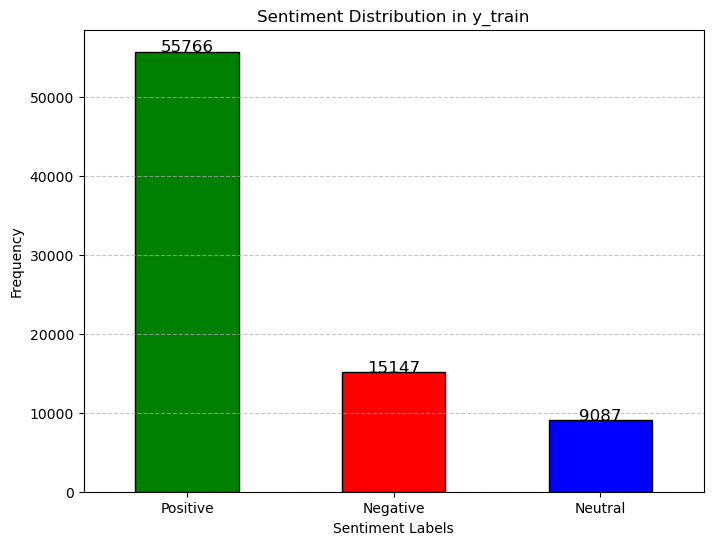

In [23]:
bar_plot(y_train)

**Sampling**

In [24]:
# Initialize RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Perform undersampling using the RandomUnderSampler
# Reshape X_train to 2D (required for RandomUnderSampler)
x_train_reshaped = x_train.values.reshape(-1, 1)

# Fit the sampler and resample the data
x_resampled, y_resampled = rus.fit_resample(x_train_reshaped, y_train)

# Convert X_resampled back to Series with the index from y_resampled (to preserve the relationship)
x_resampled = pd.Series(x_resampled.flatten(), index=y_resampled.index)

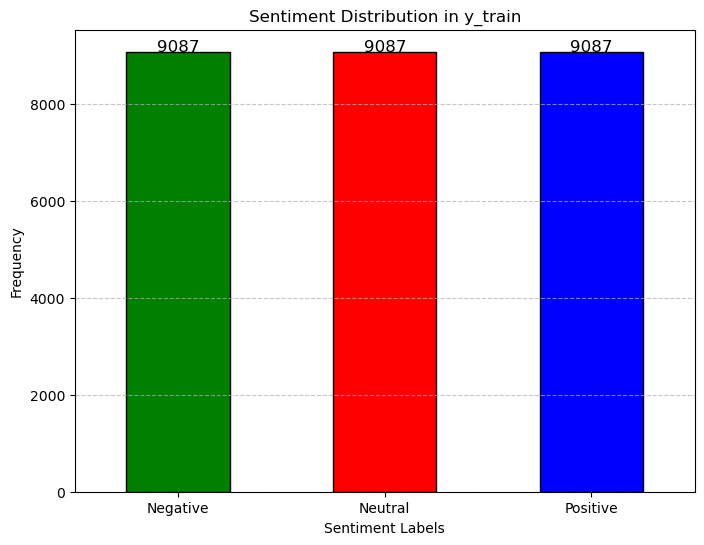

In [25]:
bar_plot(y_resampled)

**MultinomialNB Vectorizer function**

In [26]:
def vectorizer(vectorizer, x_train, y_train, x_test, y_test):
    nb_count = make_pipeline(vectorizer, MultinomialNB())

    # Start timer
    start_time = time.time()

    # Train the model on the training data
    nb_count.fit(x_train, y_train)
    end_time = time.time()

    # Predict on test and train data
    y_pred_nb_count_test = nb_count.predict(x_test)
    y_pred_nb_count_train = nb_count.predict(x_train)

    # Get predicted probabilities instead of class predictions
    y_pred_proba_test = nb_count.predict_proba(x_test)
    y_pred_proba_train = nb_count.predict_proba(x_train)


    # Calculate accuracy for test and train data
    accuracy_test = accuracy_score(y_test, y_pred_nb_count_test)
    accuracy_train = accuracy_score(y_train, y_pred_nb_count_train)

    # F1 scores for test and train data
    f1_test = f1_score(y_test, y_pred_nb_count_test, labels = class_labels, average=None)
    f1_train = f1_score(y_train, y_pred_nb_count_train, labels = class_labels, average=None)

    # Confusion matrices for test and train data
    cm_nb_count_test = confusion_matrix(y_test, y_pred_nb_count_test, labels = class_labels)
    cm_nb_count_train = confusion_matrix(y_train, y_pred_nb_count_train, labels = class_labels)

    # Calculate training time
    training_time = end_time - start_time

    print(f"Training Time: {training_time:.2f} seconds")

    # Print results for train data
    print("\nNaive Bayes (Count Vectorizer) - Train Accuracy:", accuracy_train)

    # Print the F1 scores for each class with the class name
    print("F1 Scores for each class:")
    for i, score in enumerate(f1_train):
        print(f"{class_labels[i]}: {score:.4f}")

    print("Confusion Matrix (Train):\n", cm_nb_count_train)

    # Plot confusion matrix and ROC curve for train data
    plot_confusion_matrix(cm_nb_count_train)
    plot_roc_curve(y_train, y_pred_proba_train)

    # Print results for test data
    print("\nNaive Bayes (Count Vectorizer) - Test Accuracy:", accuracy_test)

    # Print the F1 scores for each class with the class name
    print("F1 Scores for each class:")
    for i, score in enumerate(f1_test):
        print(f"{class_labels[i]}: {score:.4f}")

    print("Confusion Matrix (Test):\n", cm_nb_count_test)

    # Plot confusion matrix and ROC curve for test data
    plot_confusion_matrix(cm_nb_count_test)
    plot_roc_curve(y_test, y_pred_proba_test)

    get_top_feature_names(vectorizer, nb_count, 10)
    return nb_count

# Models

# Model 1: Naive Bayes with Count Vectorizer

**(unigrams) whith no max_features**

Training Time: 1.41 seconds

Naive Bayes (Count Vectorizer) - Train Accuracy: 0.7788782509812553
F1 Scores for each class:
Negative: 0.7696
Neutral: 0.7227
Positive: 0.8506
Confusion Matrix (Train):
 [[6779 2127  181]
 [1288 7017  782]
 [ 462 1188 7437]]


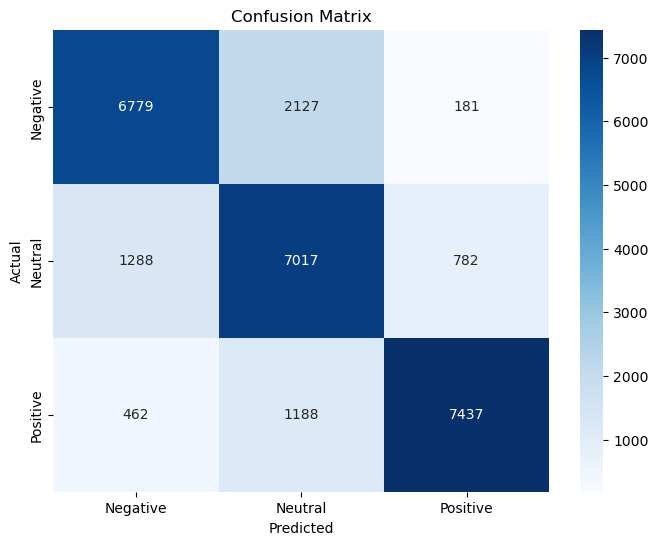

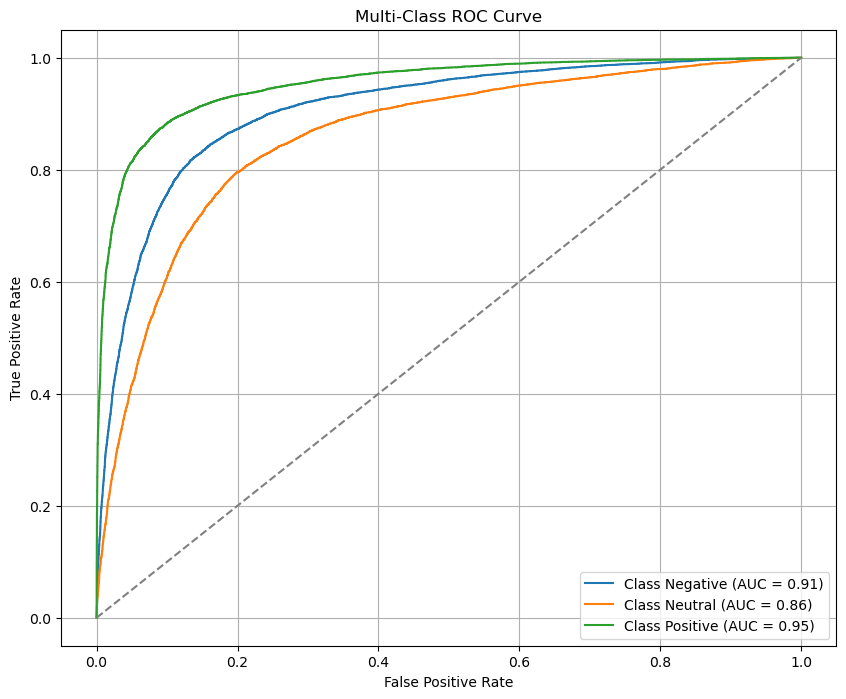


Naive Bayes (Count Vectorizer) - Test Accuracy: 0.70895
F1 Scores for each class:
Negative: 0.6716
Neutral: 0.4000
Positive: 0.8211
Confusion Matrix (Test):
 [[ 2579  1084    99]
 [  372  1585   318]
 [  967  2981 10015]]


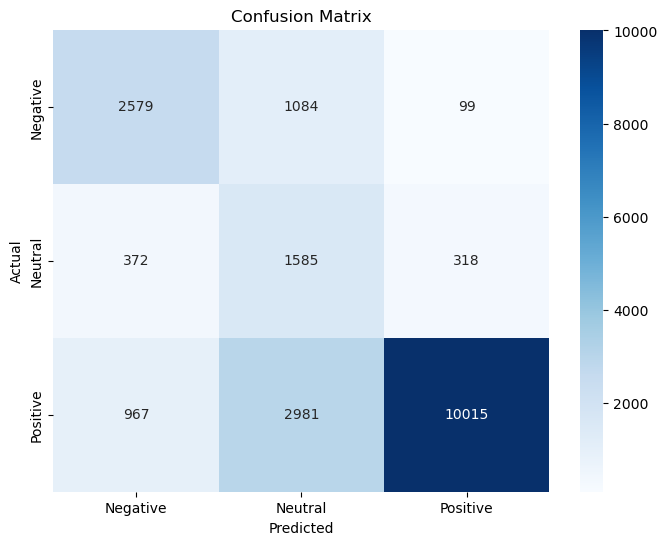

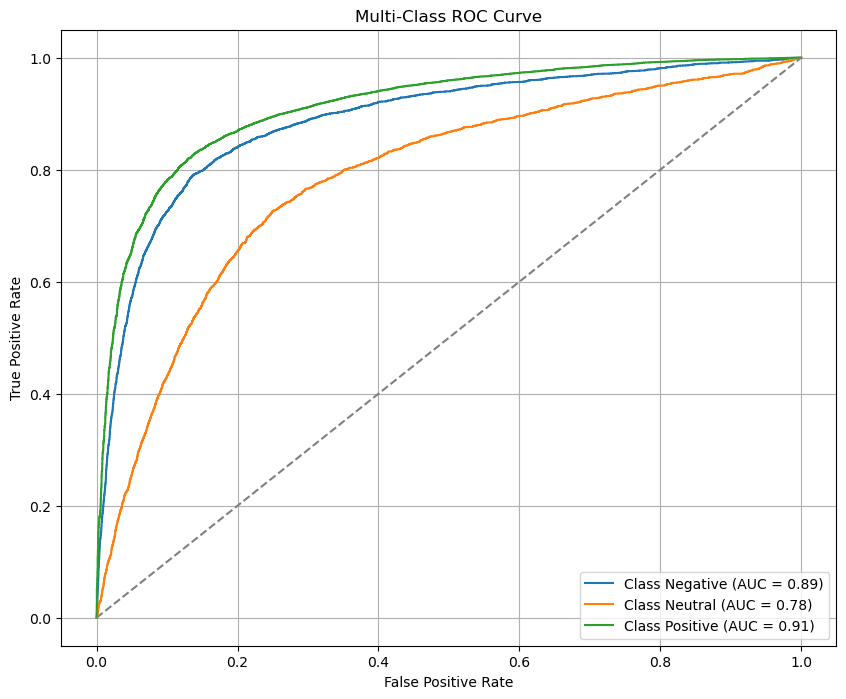


Top 10 Features for Class: Negative
food, order, place, time, get, go, like, servic, one, would

Top 10 Features for Class: Neutral
good, food, place, like, order, time, get, go, servic, would

Top 10 Features for Class: Positive
great, place, good, food, time, servic, go, get, like, love


In [27]:
model = vectorizer(CountVectorizer(ngram_range=(1, 1)), x_resampled, y_resampled, x_test, y_test)

**Using LIME to Explain Model Prediction for a Single Instance in Test**

In [28]:
print(x_test)
print(y_test)
explain_prediction_with_lime(model, x_test[75721])

75721    love elev burger need clean restaur better the...
80184    far best pizza place hendersonvil look ny styl...
19864    ive heard lot five guy year final chanc tri ca...
76699    rich kenni awesom hilari guy alway fast check ...
92991    love place season room dirt cheap peppermil to...
                               ...                        
32595    tri realli realli tri give chanc ala review up...
29313    could recommend visitor one place stop mazzaro...
37862    stanton gourmet cater knock park event santa b...
53421    here deal inout kind place expect experi kind ...
42410    perform great venu favorit squeaki disrupt cha...
Name: processed_text, Length: 20000, dtype: object
75721     Neutral
80184    Positive
19864    Negative
76699    Positive
92991    Positive
           ...   
32595    Negative
29313    Positive
37862    Positive
53421    Negative
42410    Negative
Name: label, Length: 20000, dtype: object


[('burger', 0.11143604669953615),
 ('littl', 0.10520143914367663),
 ('better', 0.08290737777872458),
 ('elev', 0.07745564830095153),
 ('there', 0.04815082855340282),
 ('love', -0.04298236819758576),
 ('restaur', 0.014649975866357657),
 ('fli', 0.01374052781045196),
 ('clean', -0.006899841969746527),
 ('need', 0.0034925831371246567)]

**(unigrams) with max_features**

Training Time: 1.39 seconds

Naive Bayes (Count Vectorizer) - Train Accuracy: 0.7788782509812553
F1 Scores for each class:
Negative: 0.7696
Neutral: 0.7227
Positive: 0.8506
Confusion Matrix (Train):
 [[6779 2127  181]
 [1288 7017  782]
 [ 462 1188 7437]]


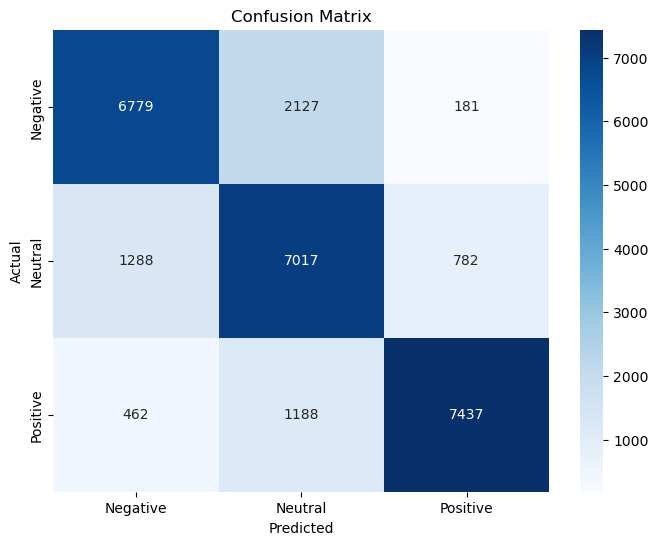

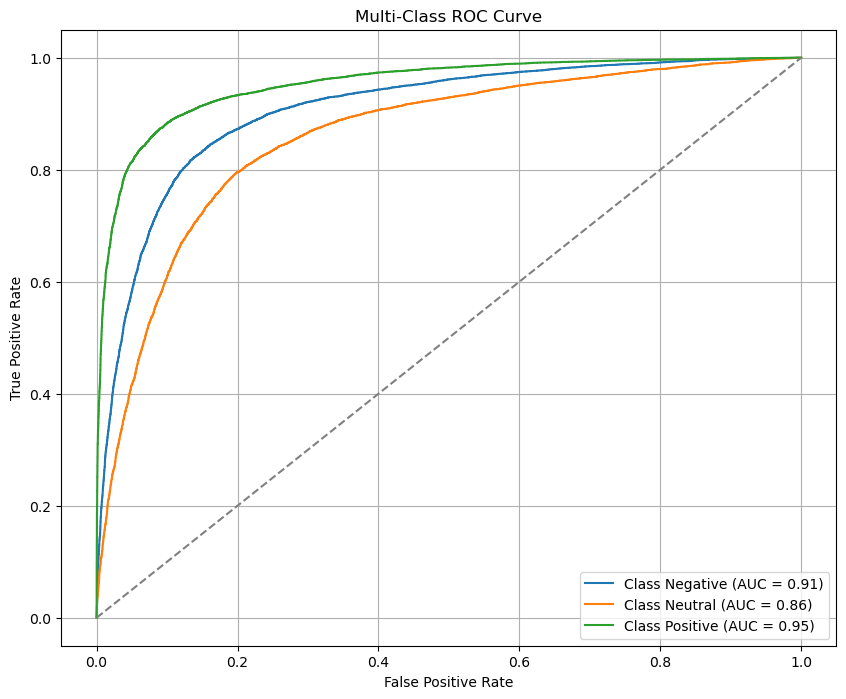


Naive Bayes (Count Vectorizer) - Test Accuracy: 0.70895
F1 Scores for each class:
Negative: 0.6716
Neutral: 0.4000
Positive: 0.8211
Confusion Matrix (Test):
 [[ 2579  1084    99]
 [  372  1585   318]
 [  967  2981 10015]]


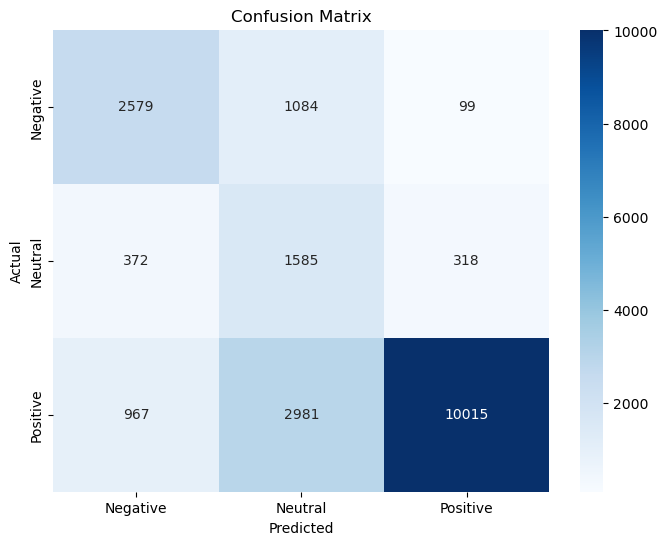

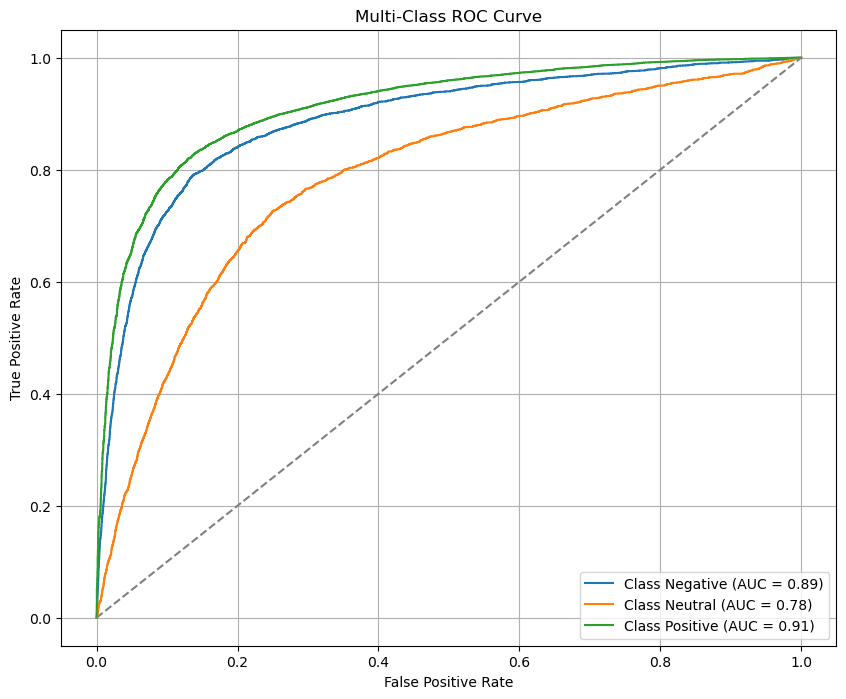


Top 10 Features for Class: Negative
food, order, place, time, get, go, like, servic, one, would

Top 10 Features for Class: Neutral
good, food, place, like, order, time, get, go, servic, would

Top 10 Features for Class: Positive
great, place, good, food, time, servic, go, get, like, love


Pipeline(steps=[('countvectorizer', CountVectorizer(max_features=50000)),
                ('multinomialnb', MultinomialNB())])

In [29]:
vectorizer(CountVectorizer(ngram_range=(1, 1), max_features = 50000), x_resampled, y_resampled, x_test, y_test)

**(unigrams + Bigrams) whith no max_features**

Training Time: 6.12 seconds

Naive Bayes (Count Vectorizer) - Train Accuracy: 0.9738454201973515
F1 Scores for each class:
Negative: 0.9713
Neutral: 0.9659
Positive: 0.9845
Confusion Matrix (Train):
 [[8808  254   25]
 [ 180 8868   39]
 [  62  153 8872]]


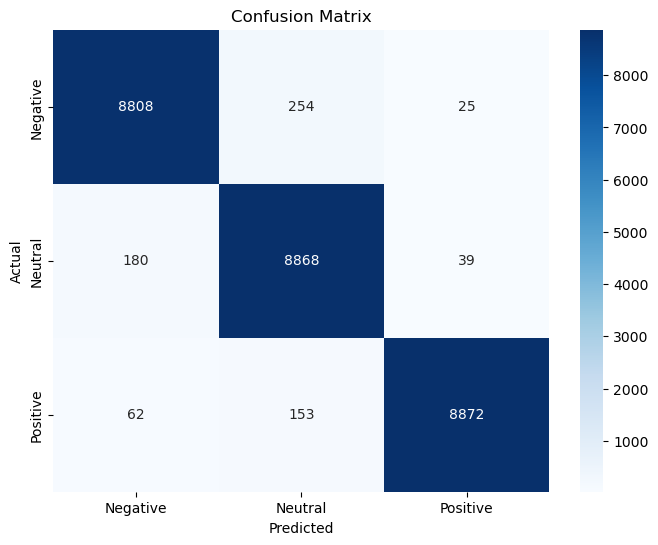

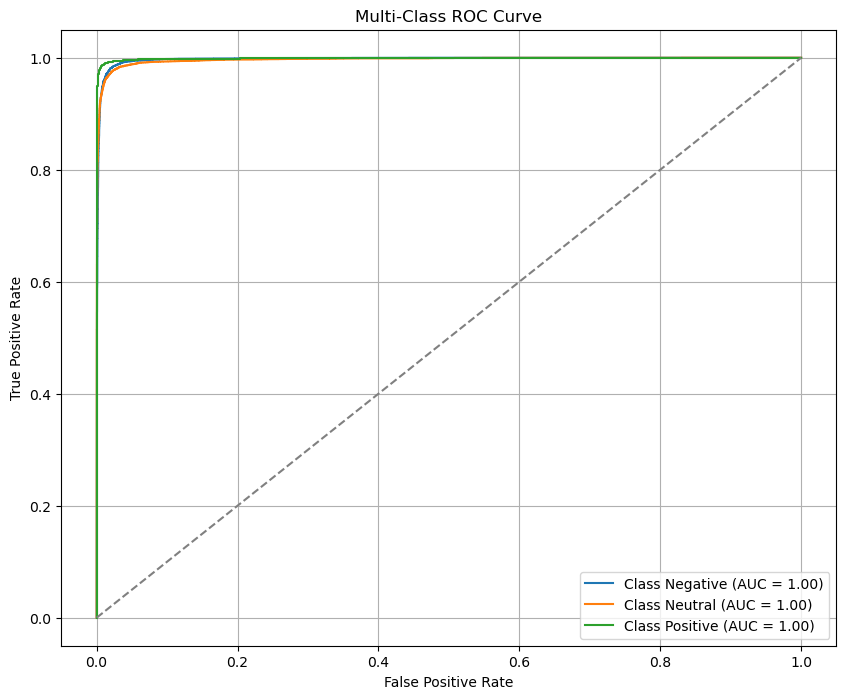


Naive Bayes (Count Vectorizer) - Test Accuracy: 0.6474
F1 Scores for each class:
Negative: 0.6879
Neutral: 0.3681
Positive: 0.7506
Confusion Matrix (Test):
 [[2709 1022   31]
 [ 388 1749  138]
 [1017 4456 8490]]


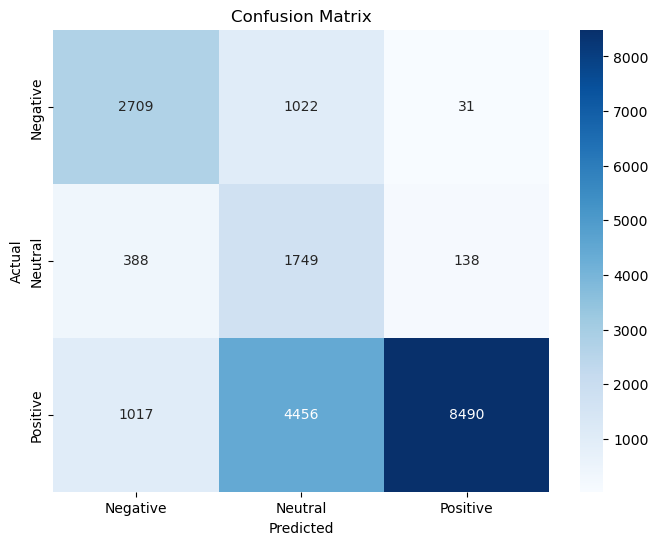

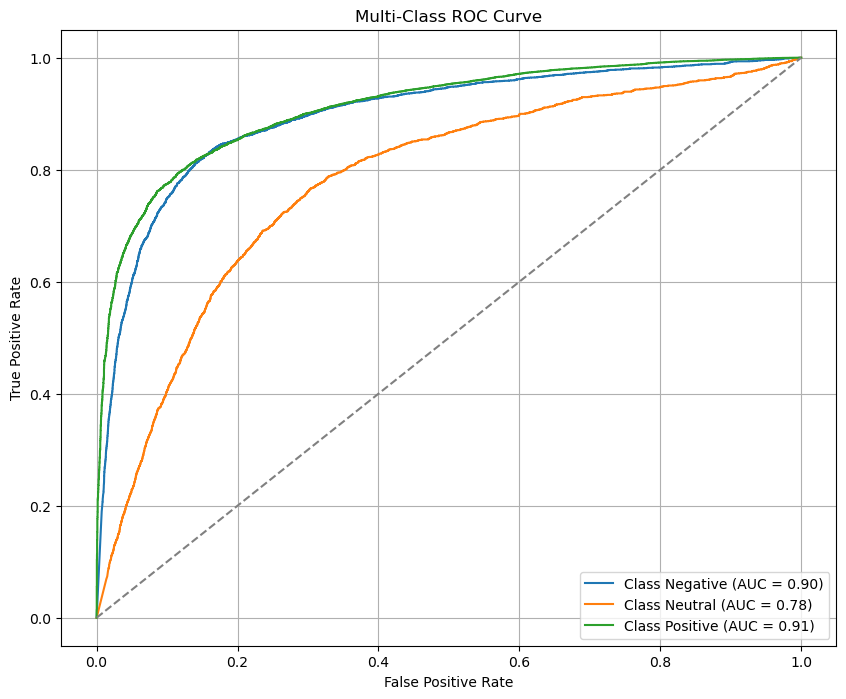


Top 10 Features for Class: Negative
food, order, place, time, get, go, like, servic, one, would

Top 10 Features for Class: Neutral
good, food, place, like, order, time, get, go, servic, would

Top 10 Features for Class: Positive
great, place, good, food, time, servic, go, get, like, love


Pipeline(steps=[('countvectorizer', CountVectorizer(ngram_range=(1, 2))),
                ('multinomialnb', MultinomialNB())])

In [30]:
vectorizer(CountVectorizer(ngram_range=(1, 2)), x_resampled, y_resampled, x_test, y_test)

**(unigrams + Bigrams) with max_features**

Training Time: 6.32 seconds

Naive Bayes (Count Vectorizer) - Train Accuracy: 0.8485382047613808
F1 Scores for each class:
Negative: 0.8360
Neutral: 0.8020
Positive: 0.9080
Confusion Matrix (Train):
 [[7407 1492  188]
 [ 958 7438  691]
 [ 268  532 8287]]


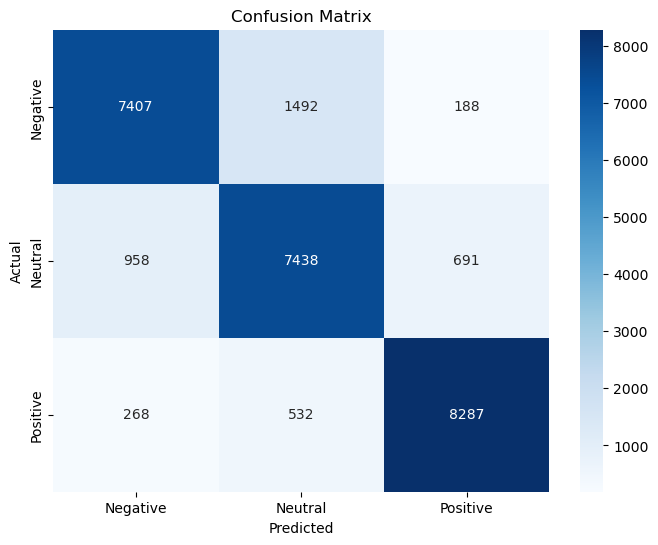

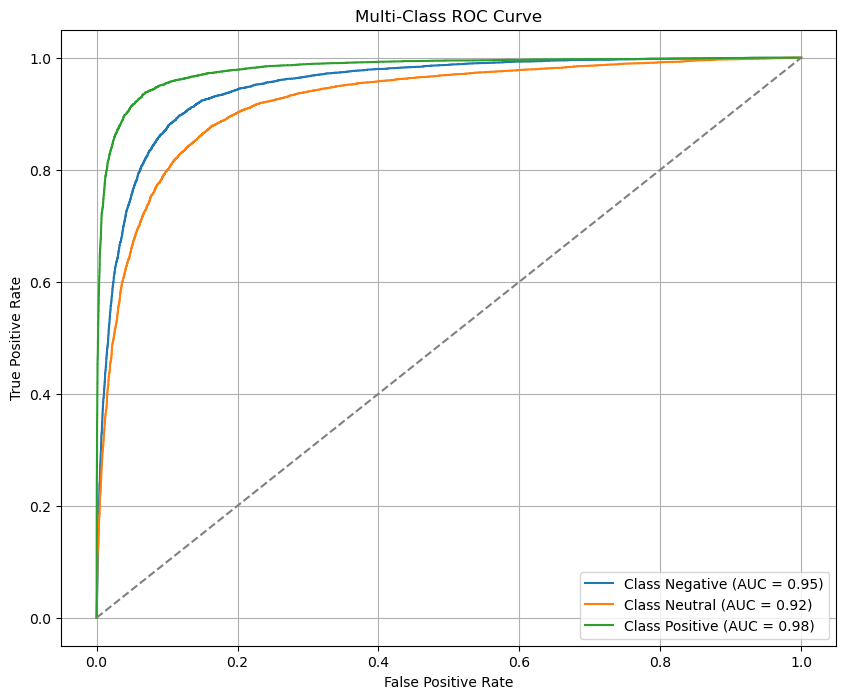


Naive Bayes (Count Vectorizer) - Test Accuracy: 0.75
F1 Scores for each class:
Negative: 0.7046
Neutral: 0.4274
Positive: 0.8565
Confusion Matrix (Test):
 [[ 2647  1014   101]
 [  366  1553   356]
 [  738  2425 10800]]


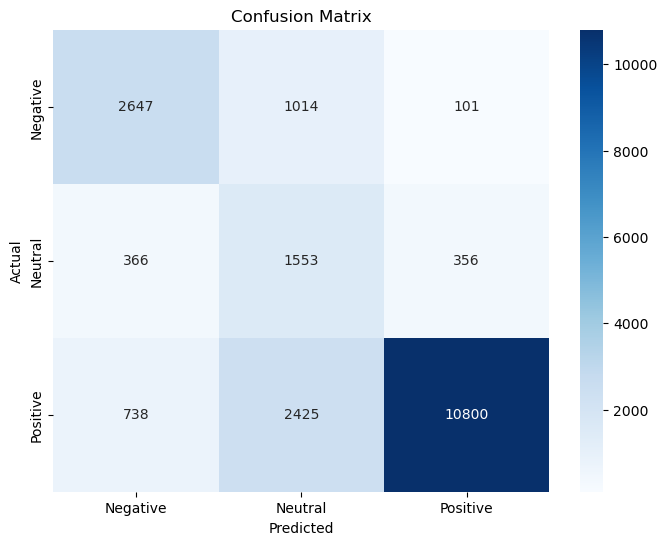

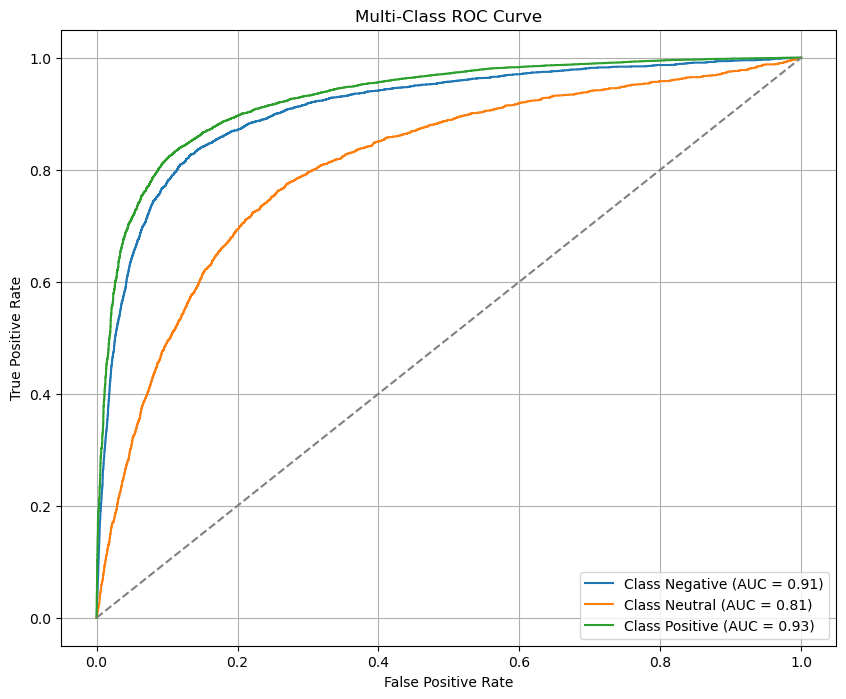


Top 10 Features for Class: Negative
food, order, place, time, get, go, like, servic, one, would

Top 10 Features for Class: Neutral
good, food, place, like, order, time, get, go, servic, would

Top 10 Features for Class: Positive
great, place, good, food, time, servic, go, get, like, love


Pipeline(steps=[('countvectorizer',
                 CountVectorizer(max_features=70000, ngram_range=(1, 2))),
                ('multinomialnb', MultinomialNB())])

In [31]:
vectorizer(CountVectorizer(ngram_range=(1, 2), max_features = 70000), x_resampled, y_resampled, x_test, y_test)

**(unigrams + Bigrams + Trigrams) whith max_features**

Training Time: 13.98 seconds

Naive Bayes (Count Vectorizer) - Train Accuracy: 0.8684934521844393
F1 Scores for each class:
Negative: 0.8567
Neutral: 0.8275
Positive: 0.9216
Confusion Matrix (Train):
 [[7603 1321  163]
 [ 831 7656  600]
 [ 229  441 8417]]


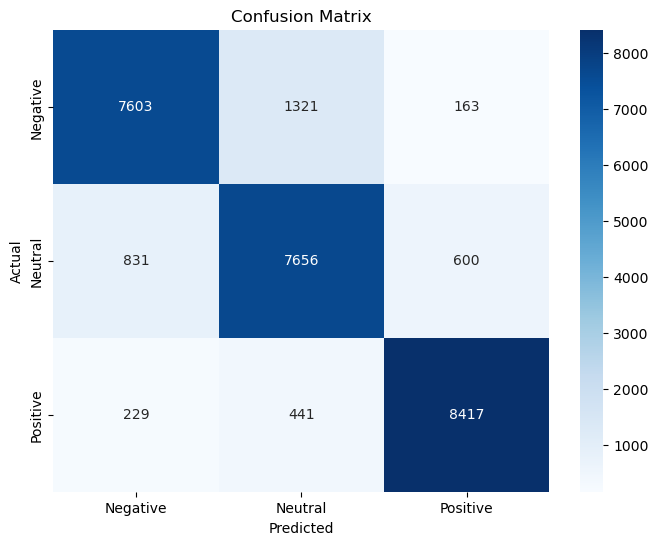

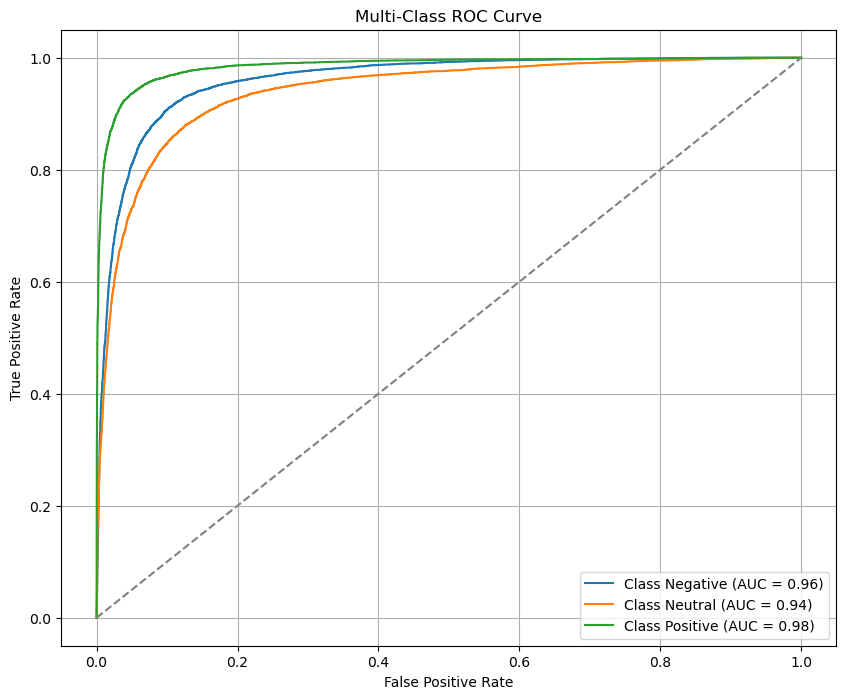


Naive Bayes (Count Vectorizer) - Test Accuracy: 0.74995
F1 Scores for each class:
Negative: 0.7106
Neutral: 0.4299
Positive: 0.8548
Confusion Matrix (Test):
 [[ 2682   986    94]
 [  364  1571   340]
 [  741  2476 10746]]


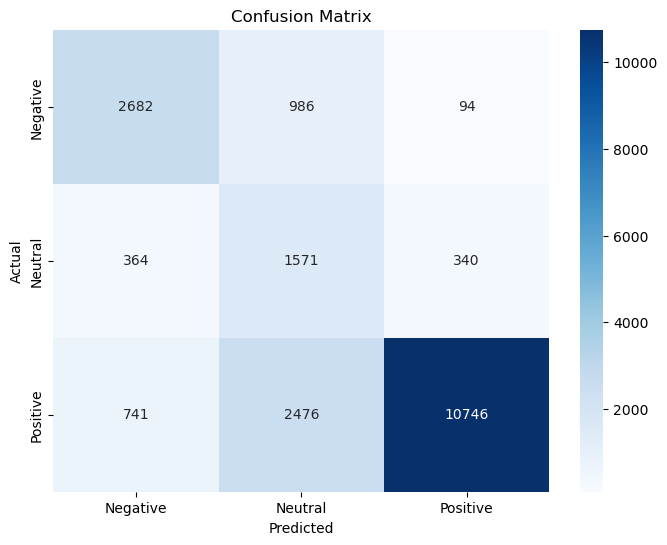

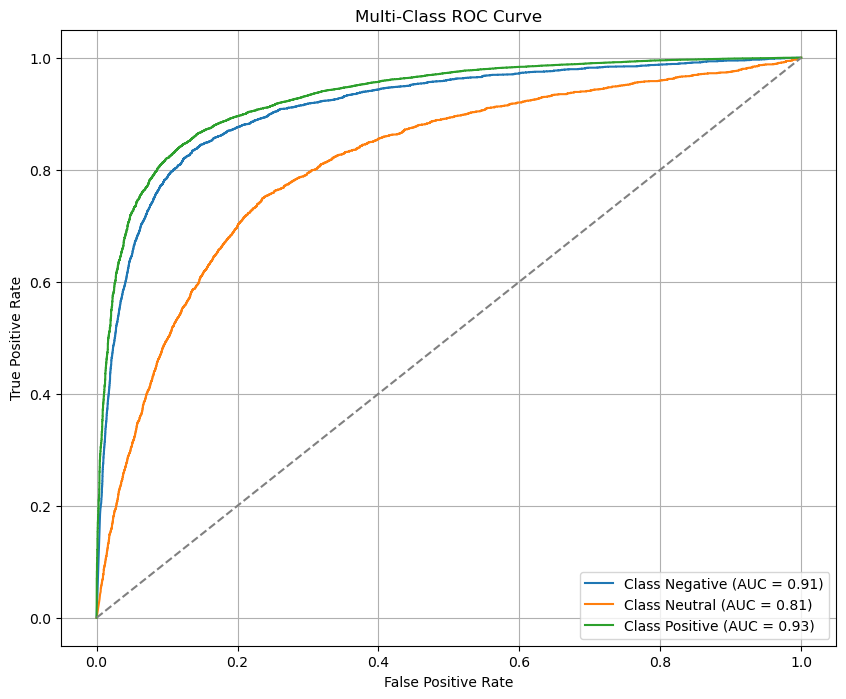


Top 10 Features for Class: Negative
food, order, place, time, get, go, like, servic, one, would

Top 10 Features for Class: Neutral
good, food, place, like, order, time, get, go, servic, would

Top 10 Features for Class: Positive
great, place, good, food, time, servic, go, get, like, love


Pipeline(steps=[('countvectorizer',
                 CountVectorizer(max_features=100000, ngram_range=(1, 3))),
                ('multinomialnb', MultinomialNB())])

In [32]:
vectorizer(CountVectorizer(ngram_range=(1, 3), max_features = 100000), x_resampled, y_resampled, x_test, y_test)

**Cross-Validation**

Fitting 5 folds for each of 27 candidates, totalling 135 fits
GridSearchCV Time: 260.47 seconds
Best Parameters from GridSearchCV:  {'countvectorizer__max_features': 50000, 'countvectorizer__ngram_range': (1, 3), 'multinomialnb__alpha': 1.0}
Best Cross-Validation Accuracy from GridSearchCV: 0.7238
Best Model Train Accuracy: 0.8272
F1 Scores for each class (Train):
Negative: 0.8180
Neutral: 0.7732
Positive: 0.8910
Confusion Matrix (Train):
 [[7224 1659  204]
 [1061 7187  839]
 [ 291  657 8139]]


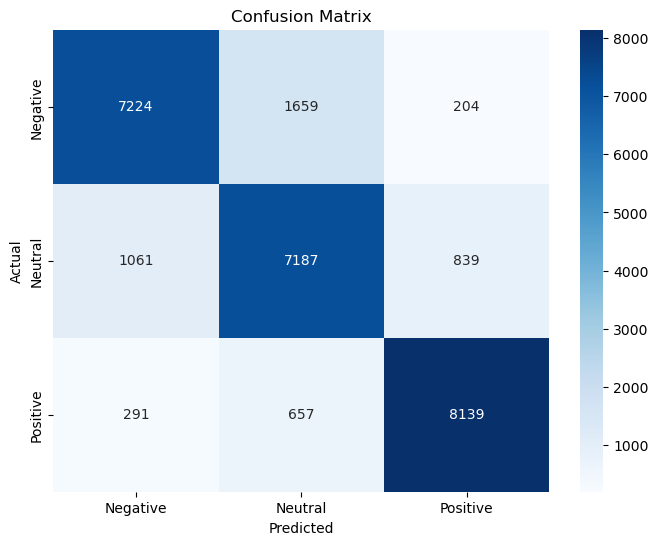

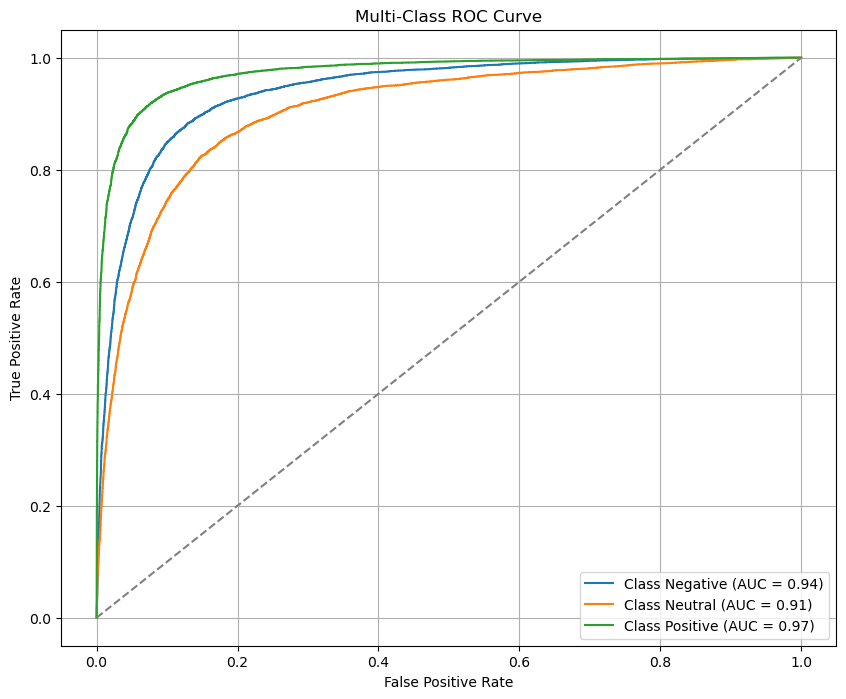

Best Model Test Accuracy: 0.7577
F1 Scores for each class (Test):
Negative: 0.7094
Neutral: 0.4335
Positive: 0.8630
Confusion Matrix (Test):
 [[ 2661  1008    93]
 [  365  1546   364]
 [  714  2303 10946]]


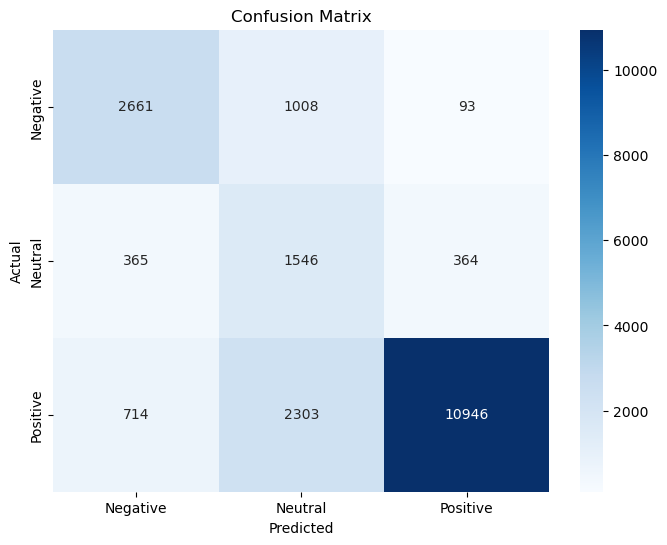

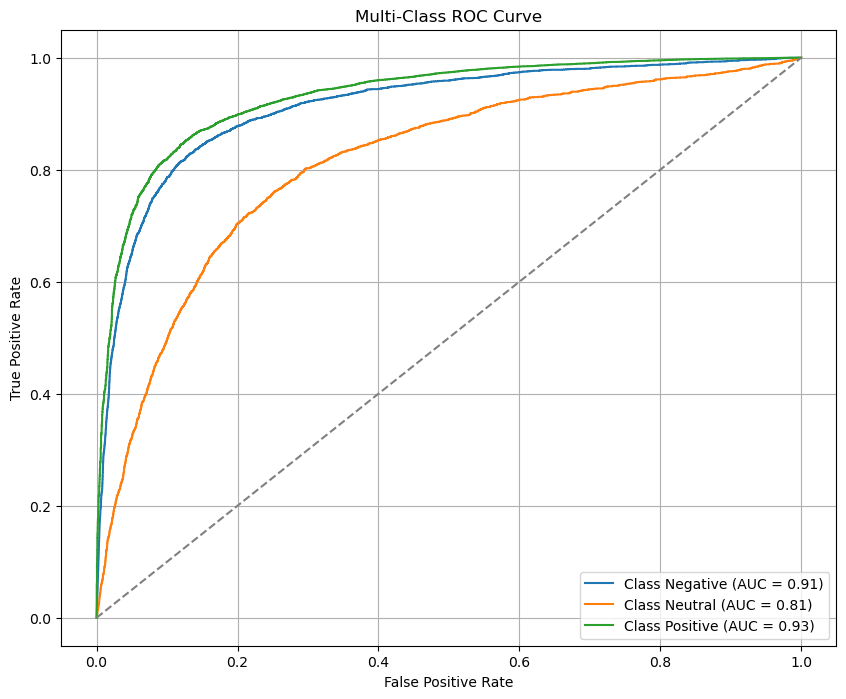

In [33]:
vectorizer = CountVectorizer(ngram_range=(1, 1))  # Default (unigrams)
param_grid = {
        'countvectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)],  # Unigrams, bigrams, trigrams
        'countvectorizer__max_features': [25000, 50000, 100000],      # Number of features to extract
        'multinomialnb__alpha': [0.1, 0.5, 1.0]                    # Smoothing parameter for Naive Bayes
    }
cross_validation(vectorizer, param_grid, x_resampled, y_resampled, x_test, y_test)